In [209]:
import pandas as pd

df = pd.read_csv('/Users/zentrovoy/Documents/BOOTCAMP/TEST/loan.csv')
df.head()




,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [211]:
(df.isnull().sum() / len(df) * 100).round(2)

Loan_ID              0.00
Gender               2.12
Married              0.49
Dependents           2.44
Education            0.00
Self_Employed        5.21
ApplicantIncome      0.00
CoapplicantIncome    0.00
LoanAmount           3.58
Loan_Amount_Term     2.28
Credit_History       8.14
Property_Area        0.00
Loan_Status          0.00
dtype: float64

In [212]:
display(df['Gender'].unique())
display(df['Married'].unique())
display(df['Education'].unique())
display(df['Loan_Status'].unique())
display(df['Property_Area'].unique())
display(df['Credit_History'].unique())


array(['Male', 'Female', nan], dtype=object)

array(['No', 'Yes', nan], dtype=object)

array(['Graduate', 'Not Graduate'], dtype=object)

array(['Y', 'N'], dtype=object)

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

array([ 1.,  0., nan])

In [213]:
df[df.isnull().any(axis=1)].shape[0]

134

In [214]:
corell = df.groupby('Loan_Status').mean(numeric_only=True)




In [215]:
df['Self_Employed'].value_counts()

Self_Employed
No     500
Yes     82
Name: count, dtype: int64

In [216]:
df[(df['Self_Employed'] == 'Yes') & (df['Loan_Status'] == 'Y')].shape[0]

56

In [217]:
invalid_income = df['ApplicantIncome'].isnull().sum() + (df['ApplicantIncome'] == 0).sum()
print(invalid_income)

0


In [218]:
df[(df['Education'] == 'Graduate') & (df['Loan_Status'] == 'Y')].shape[0]

340

In [219]:
df['Loan_Status'] = df['Loan_Status'].map({'Y':1,'N':0})

educ_loan = df.groupby('Education')['Loan_Status'].mean().round(2)
print(educ_loan)

Education
Graduate        0.71
Not Graduate    0.61
Name: Loan_Status, dtype: float64


(0.0, 1.0)

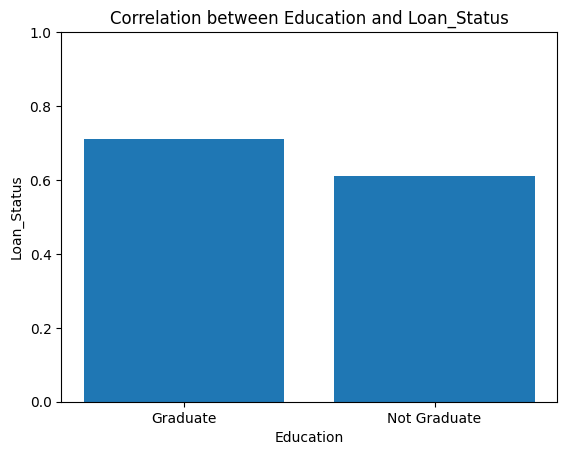

In [231]:
import matplotlib.pyplot as plt

plt.bar(educ_loan.index,educ_loan.values)
plt.title('Correlation between Education and Loan_Status')
plt.xlabel('Education')
plt.ylabel('Loan_Status')
plt.ylim(0,1)


In [ ]:
q